In [25]:
from dspl_generator import DSPLGenerator

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [2]:
amp = 5.0

dspl = DSPLGenerator(
    fov=15,

    lens_img=None,
    source1_img=None,
    source2_img=None,

    lens_amp=4*amp,
    source1_amp=amp,
    source2_amp=amp,

    telescope="euclid",
    exposure_time=600
)

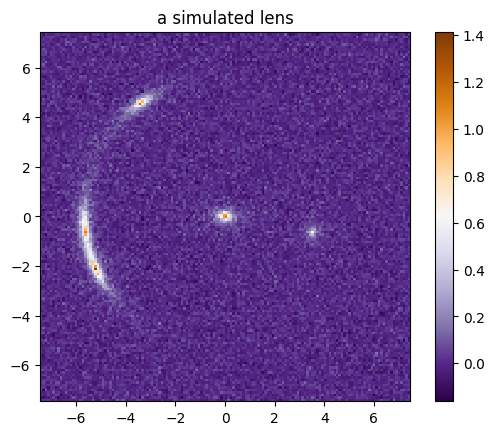

In [4]:
sim = dspl.get_simulation()

plt.imshow(sim, origin='lower', cmap='PuOr_r', extent=dspl.pixel_grid.extent)
plt.colorbar()
plt.title('a simulated lens')
plt.show()

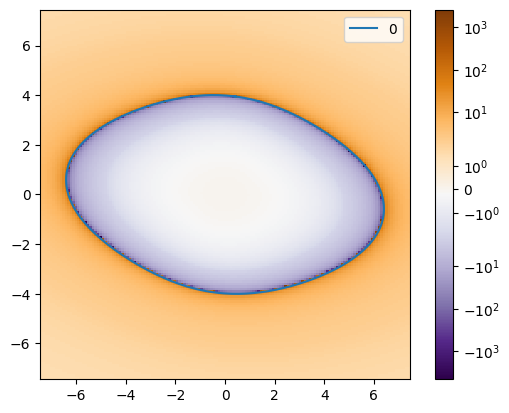

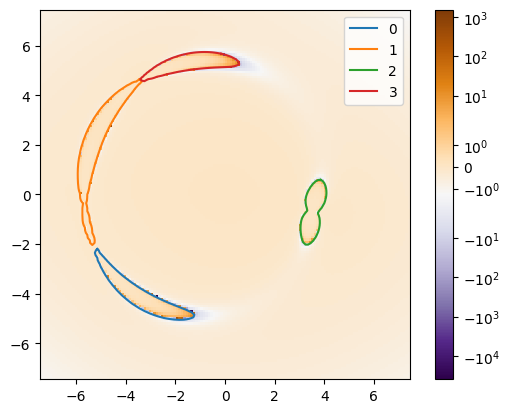

In [5]:
mu_wrts1, mu_wrts2 = dspl.get_magnification()

cc_wrts1_old, cc_wrts2_old = dspl.get_critical_curves()

plt.imshow(mu_wrts1, norm="symlog", cmap="PuOr_r", extent=dspl.pixel_grid.extent)
plt.colorbar()

for i, c in enumerate(cc_wrts1_old):
    plt.plot(c[:, 0], c[:, 1], label=i)
plt.legend()
plt.show()

plt.imshow(mu_wrts2, norm="symlog", cmap="PuOr_r", extent=dspl.pixel_grid.extent)
plt.colorbar()

for i, c in enumerate(cc_wrts2_old):
    plt.plot(c[:, 0], c[:, 1], label=i)
plt.legend()
plt.show()

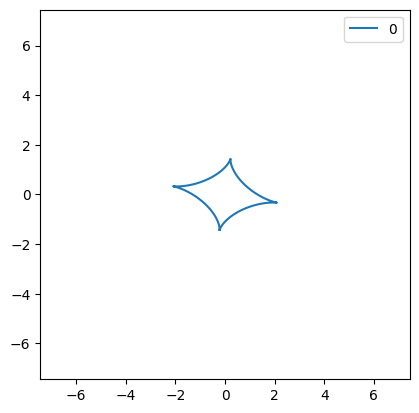

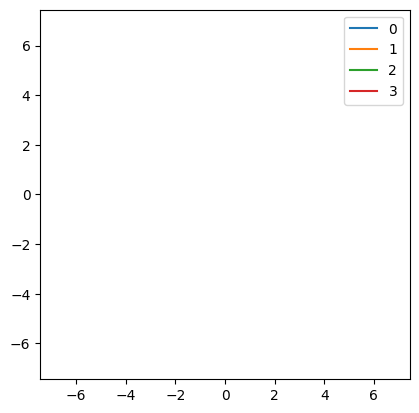

In [13]:
caustic_wrts1_old, caustic_wrts2_old = dspl.get_caustics()

xmin, xmax, ymin, ymax = dspl.pixel_grid.extent

for i, c in enumerate(caustic_wrts1_old):
    plt.plot(c[:, 0], c[:, 1], label=i)
plt.legend()

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.gca().set_aspect('equal', adjustable='box') 

plt.show()

for i, c in enumerate(caustic_wrts2_old):
    plt.plot(c[:, 0], c[:, 1], label=i)
plt.legend()

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.gca().set_aspect('equal', adjustable='box') 

plt.show()


In [19]:
mu_wrts1, mu_wrts2 = dspl.get_magnification()

init_guess_1 = [cc_wrts1_old[i][np.random.randint(len(cc_wrts1_old[i]))] for i in range(len(cc_wrts1_old))] + [[0.1e-5, 1e-6]]
cc_wrts1_new, stopping_reason1 = dspl._critical_curves(init_guess_1, plane=1, N=100_000, delta=1e-3)
print(stopping_reason1)

init_guess_2 = [cc_wrts2_old[i][np.random.randint(len(cc_wrts2_old[i]))] for i in range(len(cc_wrts2_old))] + [[0.0, -15.0]]
cc_wrts2_new, stopping_reason2 = dspl._critical_curves(init_guess_2, plane=2, N=100_000, delta=1e-2)
print(stopping_reason2)

[[2 2]
 [1 1]]
[[1 2]
 [1 0]
 [2 2]
 [0 2]
 [2 2]]


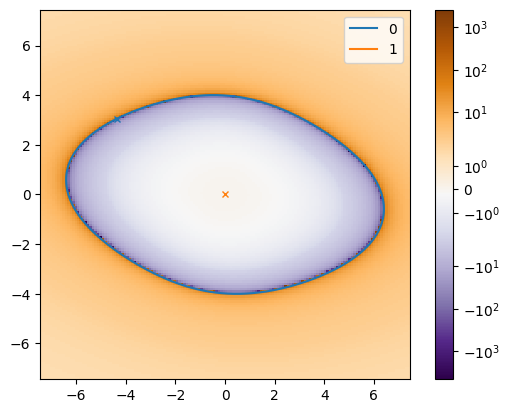

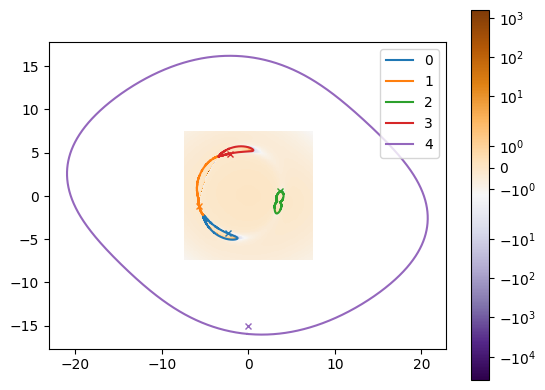

In [20]:
plt.imshow(mu_wrts1, norm="symlog", cmap="PuOr_r", extent=dspl.pixel_grid.extent)
plt.colorbar()

for i, c in enumerate(cc_wrts1_new['path']):
    plt.plot(c[:, 0], c[:, 1], label=i)
plt.legend()

for i, g in enumerate(init_guess_1):
    plt.plot(*g,'x', ms=4, color=f'C{i}')
plt.show()

plt.imshow(mu_wrts2, norm="symlog", cmap="PuOr_r", extent=np.array(dspl.pixel_grid.extent))
plt.colorbar()

for i, c in enumerate(cc_wrts2_new['path']):
    plt.plot(c[:, 0], c[:, 1], label=i)
plt.legend()

for i, g in enumerate(init_guess_2):
    plt.plot(*g,'x', ms=4, color=f'C{i}')
plt.show()

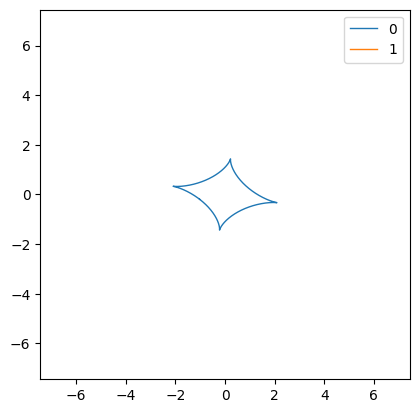

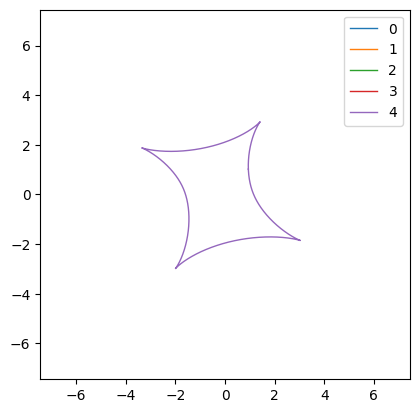

In [21]:
caustics_wrts1_x, caustics_wrts1_y = dspl._map(cc_wrts1_new['path'],1)
caustics_wrts2_x, caustics_wrts2_y = dspl._map(cc_wrts2_new['path'],2)

xmin, xmax, ymin, ymax = dspl.pixel_grid.extent

for i in range(caustics_wrts1_x.shape[0]):
    plt.plot(caustics_wrts1_x[i], caustics_wrts1_y[i], label=i, lw=1)
plt.legend()

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.gca().set_aspect('equal', adjustable='box') 

plt.show()


for i in range(caustics_wrts2_x.shape[0]):
    plt.plot(caustics_wrts2_x[i], caustics_wrts2_y[i], label=i, lw=1)
plt.legend()

plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

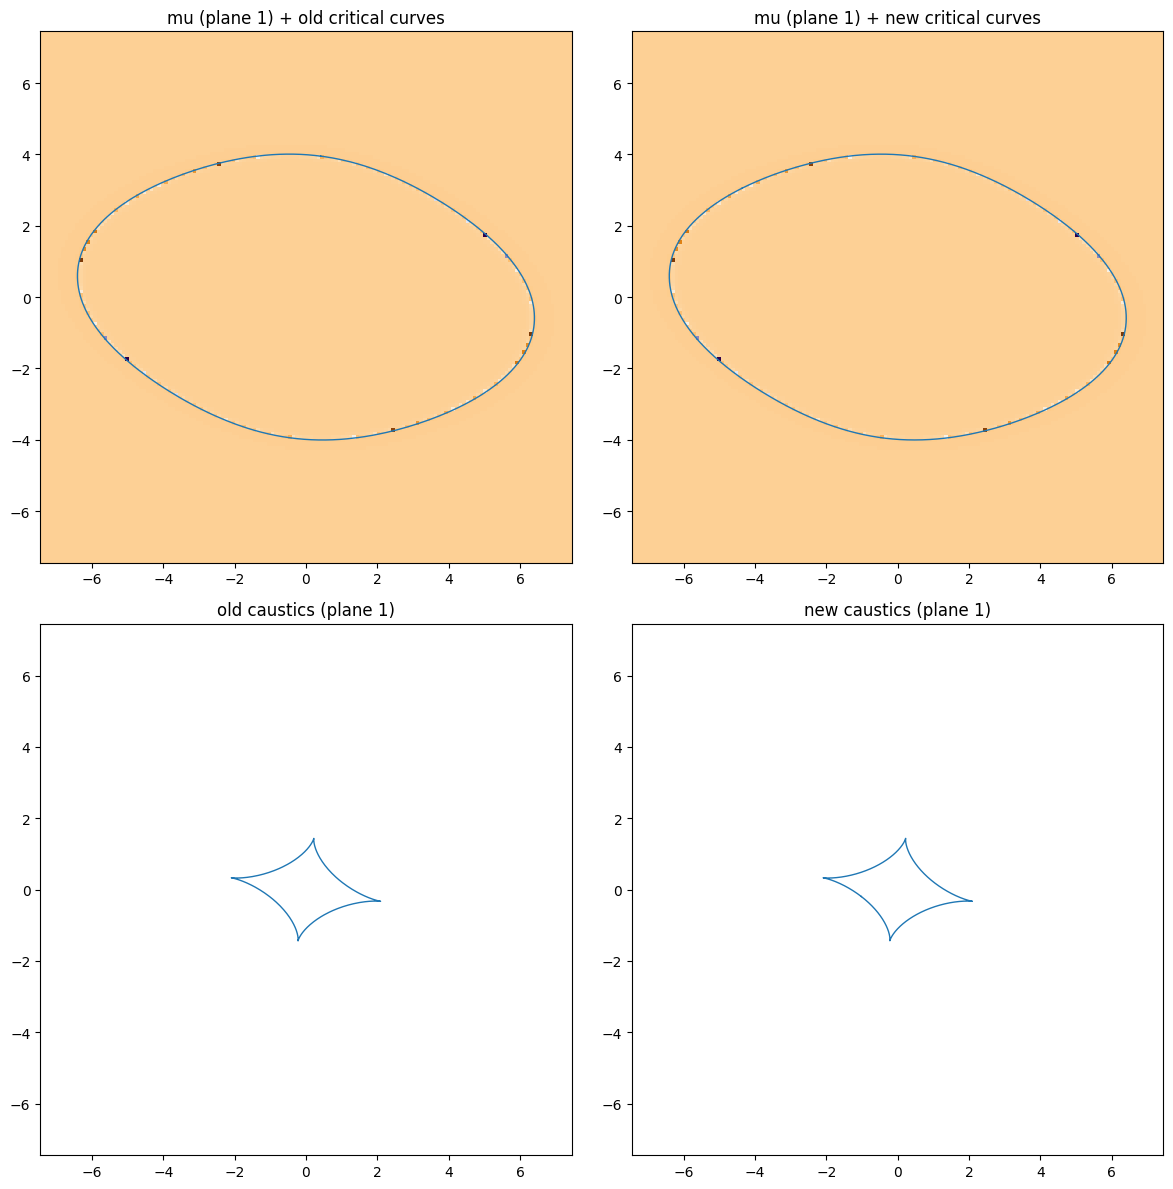

In [22]:
# ...existing code...
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

xmin, xmax, ymin, ymax = dspl.pixel_grid.extent

# 1) magnification (plane 1) + old critical curves
ax = axs[0, 0]
im = ax.imshow(mu_wrts1, origin='lower', cmap='PuOr_r', extent=dspl.pixel_grid.extent)
# fig.colorbar(im, ax=ax)
ax.set_title('mu (plane 1) + old critical curves')
for i, c in enumerate(cc_wrts1_old):
    ax.plot(c[:, 0], c[:, 1], color=f'C{i%10}', lw=1)
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')

# 2) magnification (plane 1) + new critical curves
ax = axs[0, 1]
im = ax.imshow(mu_wrts1, origin='lower', cmap='PuOr_r', extent=dspl.pixel_grid.extent)
# fig.colorbar(im, ax=ax)
ax.set_title('mu (plane 1) + new critical curves')
for i, c in enumerate(cc_wrts1_new['path']):
    ax.plot(c[:, 0], c[:, 1], color=f'C{i%10}', lw=1)
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')

# 3) old caustics (plane 1)
ax = axs[1, 0]
ax.set_title('old caustics (plane 1)')
for i, c in enumerate(caustic_wrts1_old):
    ax.plot(c[:, 0], c[:, 1], color=f'C{i%10}', lw=1)
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')

# 4) new caustics (plane 1)
ax = axs[1, 1]
ax.set_title('new caustics (plane 1)')
for i in range(caustics_wrts1_x.shape[0]):
    ax.plot(caustics_wrts1_x[i], caustics_wrts1_y[i], color=f'C{i%10}', lw=1)
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()
# ...existing code...

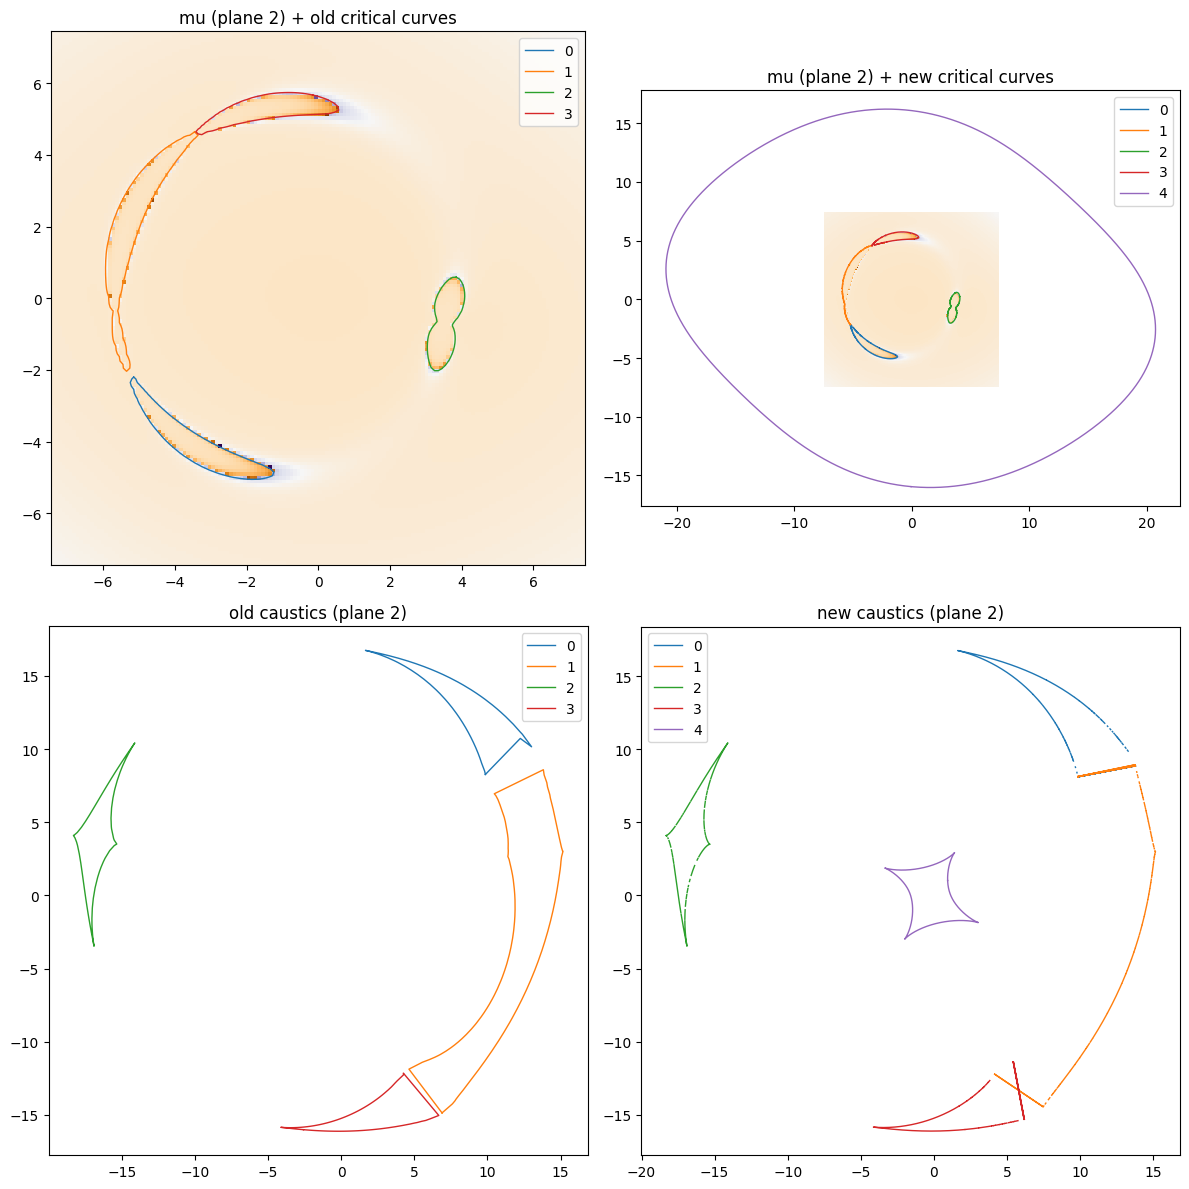

In [24]:
# ...existing code...
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

xmin, xmax, ymin, ymax = dspl.pixel_grid.extent

# 1) magnification (plane 2) + old critical curves
ax = axs[0, 0]
im = ax.imshow(mu_wrts2, origin='lower', cmap='PuOr_r', norm="symlog", extent=dspl.pixel_grid.extent)
# fig.colorbar(im, ax=ax)
ax.set_title('mu (plane 2) + old critical curves')
for i, c in enumerate(cc_wrts2_old):
    ax.plot(c[:, 0], c[:, 1], color=f'C{i%10}', lw=1, label=i)
# ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')
ax.legend()

# 2) magnification (plane 2) + new critical curves
ax = axs[0, 1]
im = ax.imshow(mu_wrts2, origin='lower', cmap='PuOr_r', norm="symlog", extent=dspl.pixel_grid.extent)
# fig.colorbar(im, ax=ax)
ax.set_title('mu (plane 2) + new critical curves')
for i, c in enumerate(cc_wrts2_new['path']):
    ax.plot(c[:, 0], c[:, 1], color=f'C{i%10}', lw=1, label=i)
# ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')
ax.legend()

# 3) old caustics (plane 2)
ax = axs[1, 0]
ax.set_title('old caustics (plane 2)')
for i, c in enumerate(caustic_wrts2_old):
    ax.plot(c[:, 0], c[:, 1], color=f'C{i%10}', lw=1, label=i)
# ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')
ax.legend()

# 4) new caustics (plane 2)
ax = axs[1, 1]
ax.set_title('new caustics (plane 2)')
for i in range(caustics_wrts2_x.shape[0]):
    ax.plot(caustics_wrts2_x[i], caustics_wrts2_y[i], color=f'C{i%10}', lw=1, label=i)
# ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')
ax.legend()

plt.tight_layout()
plt.show()